In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [3]:
df = pd.read_csv("car_evaluation.csv", header=None)
df.columns = ["buying","maint","doors","persons","lug_boot","safety","class"]

df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


## ตรวจสอบข้อมูลเบื้องต้น


In [4]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB
None

Missing values:
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


## Exploratory Data Analysis (EDA)


<Figure size 1200x600 with 0 Axes>

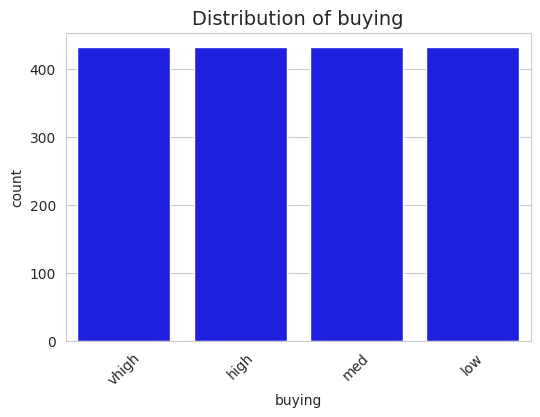

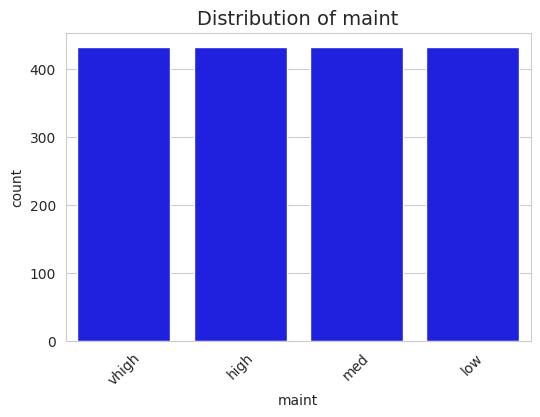

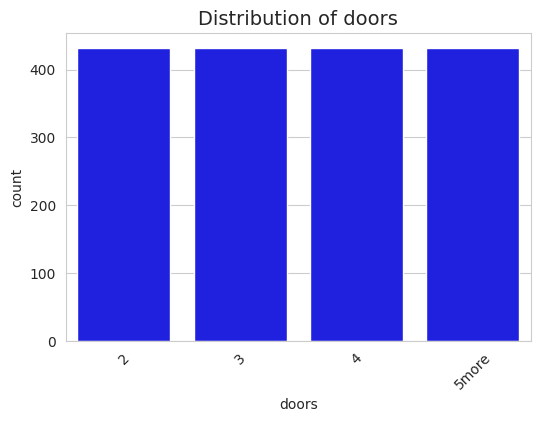

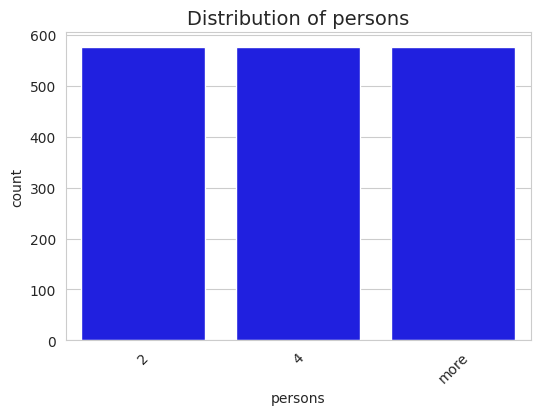

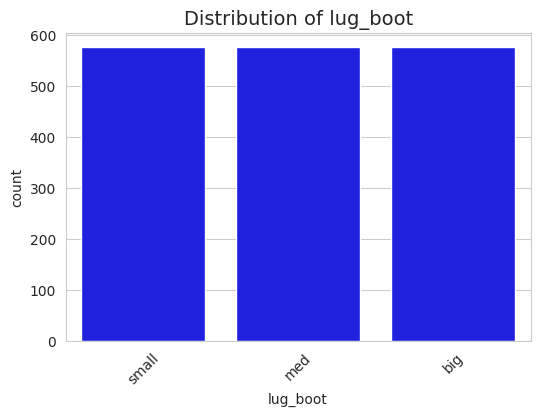

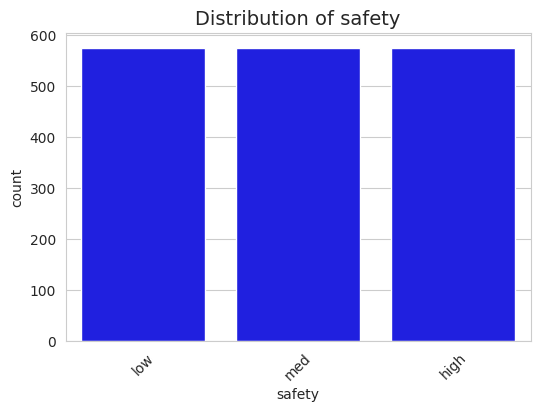

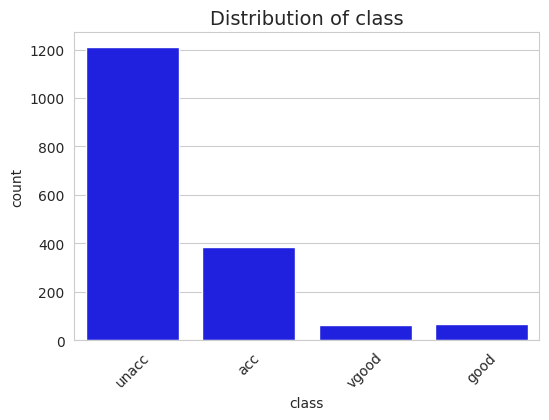

In [25]:
sns.set_style("whitegrid")
plt.figure(figsize=(12,6))
for col in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, color='blue')
    plt.title(f"Distribution of {col}", fontsize=14)
    plt.xticks(rotation=45)
    plt.show()


## Data Preprocessing



In [26]:
from sklearn.preprocessing import LabelEncoder

le_dict = {}
df_encoded = df.copy()

for col in df.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# Check class balance

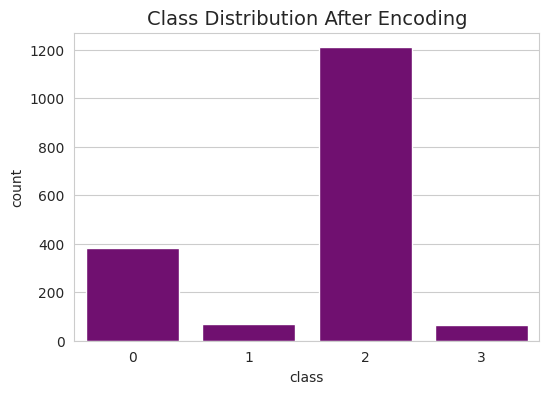

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x="class", data=df_encoded, color='purple')
plt.title("Class Distribution After Encoding", fontsize=14)
plt.show()

## แบ่งข้อมูล Train / Test

In [28]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("class", axis=1)
y = df_encoded["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## สร้างโมเดล (Random Forest)

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=150,
                       random_state=42)

##ประเมินผล

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        77
           1       0.93      0.93      0.93        14
           2       0.99      0.99      0.99       242
           3       1.00      0.92      0.96        13

    accuracy                           0.98       346
   macro avg       0.97      0.95      0.96       346
weighted avg       0.98      0.98      0.98       346



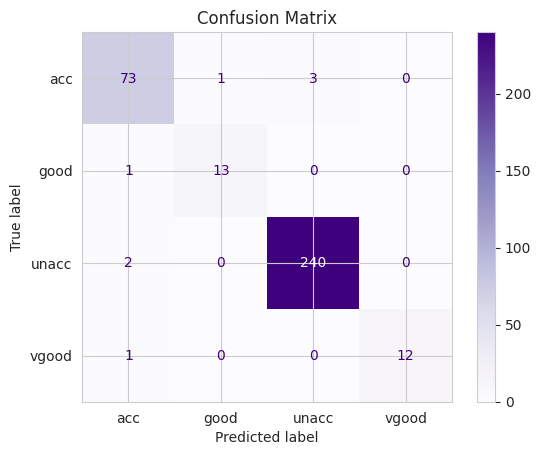

In [30]:
pred = model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_dict["class"].classes_)
disp.plot(cmap="Purples")
plt.title("Confusion Matrix")
plt.show()


##Cross Validation

In [31]:
from sklearn.model_selection import cross_val_score
cv_score = cross_val_score(model, X, y, cv=5)
print("CV Score:", cv_score.mean())

CV Score: 0.7952349836642373


## Hyperparameter Tuning

In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42, class_weight="balanced"), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
best_model = grid.best_estimator_

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


## ประเมินผลหลัง tuning


After Tuning:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95        77
           1       0.93      0.93      0.93        14
           2       0.99      0.99      0.99       242
           3       1.00      0.92      0.96        13

    accuracy                           0.98       346
   macro avg       0.97      0.95      0.96       346
weighted avg       0.98      0.98      0.98       346



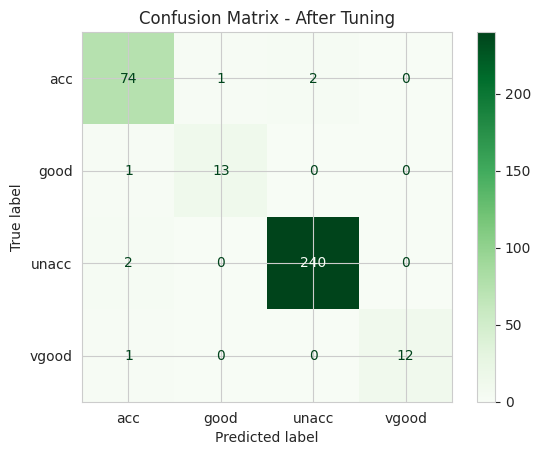

In [35]:
pred2 = best_model.predict(X_test)
print("\nAfter Tuning:")
print(classification_report(y_test, pred2))

cm2 = confusion_matrix(y_test, pred2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=le_dict["class"].classes_)
disp2.plot(cmap="Greens")
plt.title("Confusion Matrix - After Tuning")
plt.show()

## Save Model


In [36]:
joblib.dump(best_model, "model.pkl")
joblib.dump(le_dict, "encoders.pkl")
print("Save model เรียบร้อย ✅")

Save model เรียบร้อย ✅
